Algoritmo K-Means: Guia Prático (Conteúdo adaptado de Jake VanderPlas - [Algoritmo K-Means](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.11-K-Means.ipynb#scrollTo=l2HCPEoP4qC0) )

## k-Means Clustering

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import numpy as np

**Introdução ao k-Means**

O algoritmo k-means busca um número predeterminado de clusters em um conjunto de dados multidimensional não rotulado. Ele realiza isso usando uma concepção simples de como seria o agrupamento ideal:

O centro do cluster é a média aritmética de todos os pontos pertencentes ao cluster.

Cada ponto está mais próximo do seu próprio centro de cluster do que dos centros de outros clusters.

Essas duas premissas são a base do modelo k-means. Em breve, vamos nos aprofundar em como o algoritmo chega a essa solução, mas por enquanto, vamos dar uma olhada em um conjunto de dados simples e ver o resultado do k-means.

Primeiro, vamos gerar um conjunto de dados bidimensional contendo quatro blobs distintos. Para enfatizar que este é um algoritmo não supervisionado, vamos omitir os rótulos da visualização (veja a figura a seguir):

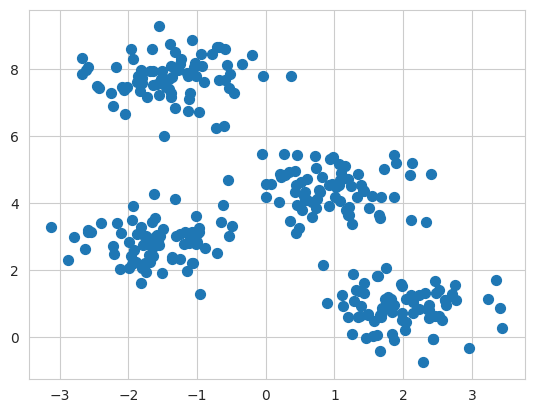

In [4]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

Visualmente, é relativamente fácil identificar os quatro agrupamentos. O algoritmo k-means faz isso automaticamente e, no Scikit-Learn, utiliza a API de estimador típica:

In [5]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

Vamos visualizar os resultados plotando os dados coloridos por esses rótulos (a figura a seguir). Também plotaremos os centros dos clusters, conforme determinado pelo estimador k-means:

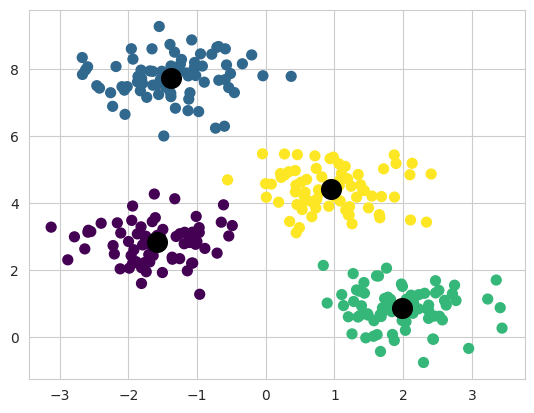

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200);

A boa notícia é que o algoritmo k-means (pelo menos neste caso simples) atribui os pontos aos clusters de forma muito semelhante à maneira como os atribuiríamos visualmente. Mas você pode estar se perguntando como esse algoritmo encontra esses clusters tão rapidamente: afinal, o número de combinações possíveis de atribuições de clusters é exponencial em relação ao número de pontos de dados — uma busca exaustiva seria muito, muito custosa. Felizmente para nós, essa busca exaustiva não é necessária: em vez disso, a abordagem típica do k-means envolve uma abordagem iterativa intuitiva conhecida como maximização da expectativa.

**Expectativa-Maximização**

O algoritmo de Expectativa-Maximização (E-M) é um algoritmo poderoso que surge em diversos contextos dentro da ciência de dados. O k-means é uma aplicação particularmente simples e fácil de entender desse algoritmo, e vamos analisá-lo brevemente aqui. Resumidamente, a abordagem de Expectativa-Maximização consiste no seguinte procedimento:

1.   Estimar alguns centros de cluster.
2.   Repetir até a convergência:
  1.   Etapa E: Atribuir pontos ao centro de cluster mais próximo.
  2.   Etapa M: Definir os centros de cluster como a média dos pontos atribuídos a eles.









A Etapa E, ou etapa de expectativa, recebe esse nome porque envolve atualizar nossa expectativa sobre a qual cluster cada ponto pertence. A Etapa M, ou etapa de maximização, recebe esse nome porque envolve maximizar alguma função de aptidão que define as localizações dos centros de cluster — neste caso, essa maximização é alcançada calculando a média simples dos dados em cada cluster.

A literatura sobre esse algoritmo é vasta, mas pode ser resumida da seguinte forma: em circunstâncias típicas, cada repetição da Etapa E e da Etapa M sempre resultará em uma estimativa melhor das características do cluster. Podemos visualizar o algoritmo conforme mostrado na figura a seguir. Para a inicialização específica apresentada aqui, os clusters convergem em apenas três iterações.

O algoritmo k-means é suficientemente simples para que possamos escrevê-lo em poucas linhas de código. A seguir, apresentamos uma implementação bastante básica (veja a figura abaixo):

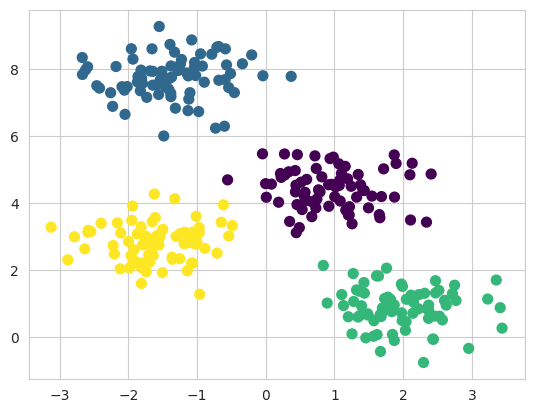

In [7]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. Assign labels based on closest center
        labels = pairwise_distances_argmin(X, centers)

        # 2b. Find new centers from means of points
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. Check for convergence
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

A maioria das implementações bem testadas fará um pouco mais do que isso internamente, mas a função anterior fornece a essência da abordagem de maximização da expectativa.

Há algumas ressalvas a serem consideradas ao usar o algoritmo de maximização da expectativa:

**O resultado globalmente ótimo pode não ser alcançado.**

Primeiro, embora o procedimento E-M garanta a melhoria do resultado em cada etapa, não há garantia de que ele levará à melhor solução global. Por exemplo, se usarmos uma semente aleatória diferente em nosso procedimento simples, os palpites iniciais específicos levarão a resultados ruins (veja a figura a seguir):

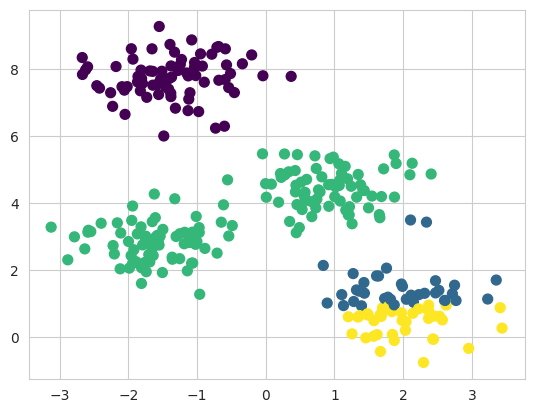

In [8]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

Neste caso, a abordagem E-M convergiu, mas não para uma configuração globalmente ótima. Por esse motivo, é comum executar o algoritmo com múltiplos valores iniciais, como o Scikit-Learn faz por padrão (o número é definido pelo parâmetro `n_init`, que tem o valor padrão de 10).

**O número de clusters deve ser selecionado previamente.**

Outro desafio comum com o k-means é que você precisa informar quantos clusters espera: ele não consegue aprender o número de clusters a partir dos dados. Por exemplo, se pedirmos ao algoritmo para identificar seis clusters, ele prosseguirá sem problemas e encontrará os seis melhores clusters, como mostrado na Figura

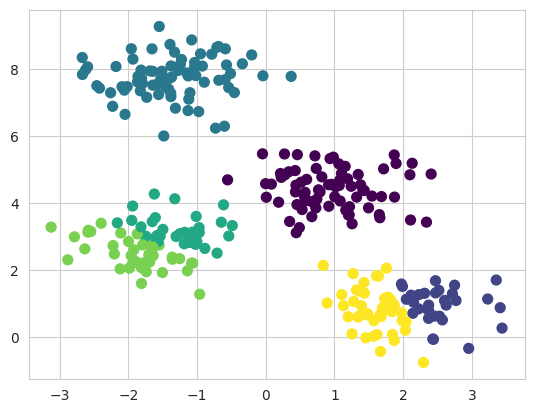

In [9]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

A questão de saber se o resultado é significativo é difícil de responder definitivamente; uma abordagem bastante intuitiva, mas que não discutiremos aqui, é chamada de [análise de silhueta](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html).

Alternativamente, você pode usar um algoritmo de agrupamento mais complexo que tenha uma medida quantitativa melhor da aptidão por número de clusters (por exemplo, modelos de mistura gaussiana; veja [Em Detalhe: Modelos de Mistura Gaussiana](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.12-Gaussian-Mixtures.ipynb)) ou que possa escolher um número adequado de clusters (por exemplo, DBSCAN, mean-shift ou propagação de afinidade, todos disponíveis no submódulo `sklearn.cluster`).

**O k-means é limitado a limites de cluster lineares.**

As premissas fundamentais do modelo k-means (os pontos estarão mais próximos do centro do seu próprio cluster do que de outros) significam que o algoritmo frequentemente será ineficaz se os clusters tiverem geometrias complexas.

Em particular, os limites entre os clusters do k-means serão sempre lineares, o que significa que ele falhará para limites mais complexos. Considere os seguintes dados, juntamente com os rótulos de cluster encontrados pela abordagem típica do k-means (veja a figura a seguir):

In [10]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

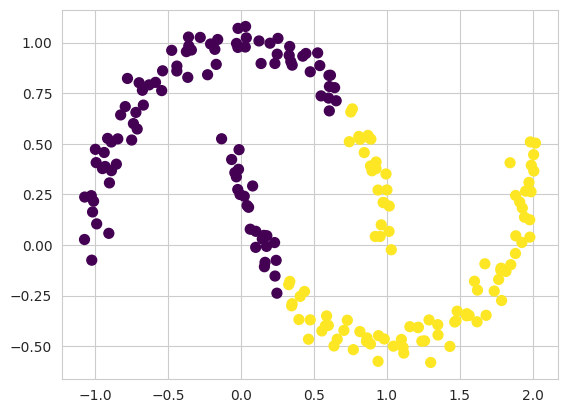

In [11]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

Essa situação lembra a discussão em ["Em Detalhe: Máquinas de Vetores de Suporte"](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.07-Support-Vector-Machines.ipynb), onde usamos uma transformação de kernel para projetar os dados em uma dimensão superior, onde uma separação linear é possível. Podemos imaginar usar o mesmo truque para permitir que o k-means descubra limites não lineares.

Uma versão desse k-means kernelizado está implementada no Scikit-Learn dentro do estimador `SpectralClustering`. Ele usa o grafo dos vizinhos mais próximos para calcular uma representação de dimensão superior dos dados e, em seguida, atribui rótulos usando um algoritmo k-means (veja a figura a seguir):

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


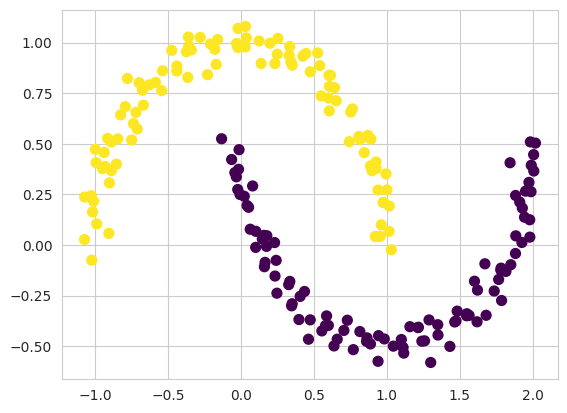

In [12]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

We see that with this kernel transform approach, the kernelized k-means is able to find the more complicated nonlinear boundaries between clusters.

O k-means pode ser lento para um grande número de amostras.

Como cada iteração do k-means precisa acessar todos os pontos do conjunto de dados, o algoritmo pode se tornar relativamente lento à medida que o número de amostras aumenta. Você pode se perguntar se esse requisito de usar todos os dados em cada iteração pode ser flexibilizado; por exemplo, você poderia usar apenas um subconjunto dos dados para atualizar os centros dos clusters a cada passo. Essa é a ideia por trás dos algoritmos k-means baseados em lotes, uma forma dos quais é implementada em `sklearn.cluster.MiniBatchKMeans.` A interface para isso é a mesma do `k-means` padrão; veremos um exemplo de seu uso à medida que continuarmos nossa discussão.

**Exemplos**

Ao levarmos em consideração essas limitações do algoritmo, podemos usar o k-means a nosso favor em diversas situações. Vamos agora analisar alguns exemplos.

**Exemplo 1: k-Means em Dígitos**

Para começar, vamos dar uma olhada na aplicação do k-means aos mesmos dados simples de dígitos que vimos em [Análise Detalhada: Árvores de Decisão e Florestas Aleatórias](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.08-Random-Forests.ipynb) e [Análise Detalhada: Análise de Componentes Principais](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.09-Principal-Component-Analysis.ipynb). Aqui, tentaremos usar o k-means para identificar dígitos semelhantes sem usar as informações de rótulo originais; isso pode ser semelhante a um primeiro passo para extrair significado de um novo conjunto de dados sobre o qual você não tem nenhuma informação de rótulo a priori.

Começaremos carregando o conjunto de dados e, em seguida, encontraremos os clusters. Lembre-se de que o conjunto de dados de dígitos consiste em 1.797 amostras com 64 características, onde cada uma das 64 características é o brilho de um pixel em uma imagem de 8 × 8 pixels:

In [13]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

O agrupamento pode ser realizado como fizemos anteriormente:

In [14]:
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

O resultado são 10 agrupamentos em 64 dimensões. Observe que os próprios centros dos agrupamentos são pontos de 64 dimensões e podem ser interpretados como representando o dígito "típico" dentro do agrupamento. Vejamos como esses centros de agrupamento se parecem (veja a figura a seguir):

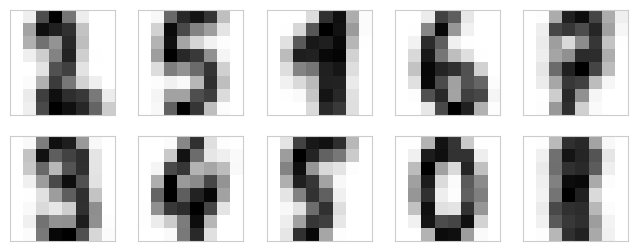

In [15]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

Observamos que, mesmo sem os rótulos, o `K-Means` consegue encontrar agrupamentos cujos centros são dígitos reconhecíveis, com talvez a exceção de 1 e 8.

Como o K-Means não sabe nada sobre as identidades dos agrupamentos, os rótulos de 0 a 9 podem estar permutados. Podemos corrigir isso associando cada rótulo de agrupamento aprendido aos rótulos reais encontrados nos agrupamentos:

In [16]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

Agora podemos verificar a precisão do nosso agrupamento não supervisionado na identificação de dígitos semelhantes nos dados:

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

Com um algoritmo k-means simples, descobrimos o agrupamento correto para 80% dos dígitos de entrada! Vejamos a matriz de confusão correspondente, visualizada na figura a seguir:

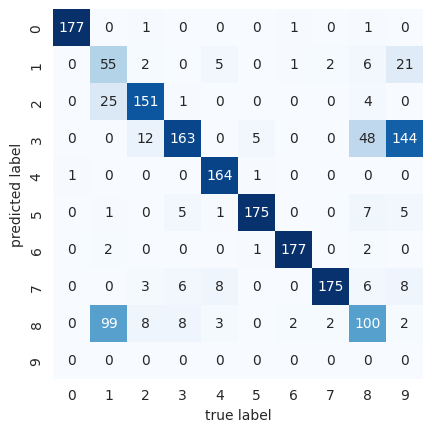

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d',
            cbar=False, cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

Como era de se esperar pelos centros dos clusters que visualizamos anteriormente, o principal ponto de confusão está entre os números 8 e 1. Mas isso ainda demonstra que, usando o k-means, podemos essencialmente construir um classificador de dígitos sem referência a quaisquer rótulos conhecidos!

Só por curiosidade, vamos tentar ir ainda mais longe. Podemos usar o algoritmo t-SNE (t-distributed stochastic neighbor embedding, mencionado em ["Aprofundando: Aprendizado de Variedades"](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.10-Manifold-Learning.ipynb)) para pré-processar os dados antes de executar o k-means. O t-SNE é um algoritmo de incorporação não linear particularmente eficaz em preservar pontos dentro dos clusters. Vejamos como ele se comporta:

In [19]:
from sklearn.manifold import TSNE

# Project the data: this step will take several seconds
tsne = TSNE(n_components=2, init='random',
            learning_rate='auto',random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# Compute the clusters
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# Permute the labels
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# Compute the accuracy
accuracy_score(digits.target, labels)

0.9410127991096272

Isso representa uma precisão de classificação de 94% sem usar os rótulos. Esse é o poder do aprendizado não supervisionado quando usado com cuidado: ele pode extrair informações do conjunto de dados que seriam difíceis de extrair manualmente ou visualmente.

**Exemplo 2: k-Means para Compressão de Cores**

Uma aplicação interessante de agrupamento (clustering) é na compressão de cores em imagens (este exemplo foi adaptado de ["Quantização de Cores Usando K-Means"](https://scikit-learn.org/stable/auto_examples/cluster/plot_face_compress.html) do Scikit-Learn). Por exemplo, imagine que você tenha uma imagem com milhões de cores. Na maioria das imagens, um grande número de cores não será usado e muitos pixels na imagem terão cores semelhantes ou até idênticas.

Por exemplo, considere a imagem mostrada na figura a seguir, que é do módulo `datasets` do Scikit-Learn (para que isso funcione, você precisará ter o pacote `PIL` do Python instalado): (Para uma versão colorida desta e das imagens seguintes, consulte a versão online deste livro).

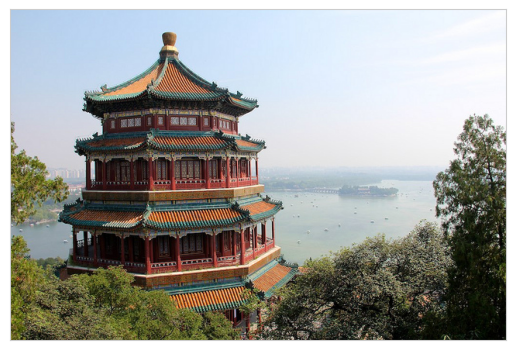

In [20]:
# Note: this requires the PIL package to be installed
from sklearn.datasets import load_sample_image
china = load_sample_image("china.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(china);

A própria imagem é armazenada em uma matriz tridimensional de tamanho (altura, largura, RGB), contendo as contribuições de vermelho/azul/verde como números inteiros de 0 a 255:

In [21]:
china.shape

(427, 640, 3)

Uma maneira de visualizar esse conjunto de pixels é como uma nuvem de pontos em um espaço de cores tridimensional. Redimensionaremos os dados para `[n_samples, n_features]` e reescalaremos as cores para que fiquem entre 0 e 1:

In [22]:
data = china / 255.0  # use 0...1 scale
data = data.reshape(-1, 3)
data.shape

(273280, 3)

Podemos visualizar esses pixels nesse espaço de cores, usando um subconjunto de 10.000 pixels para maior eficiência (veja a figura a seguir):

In [23]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.default_rng(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

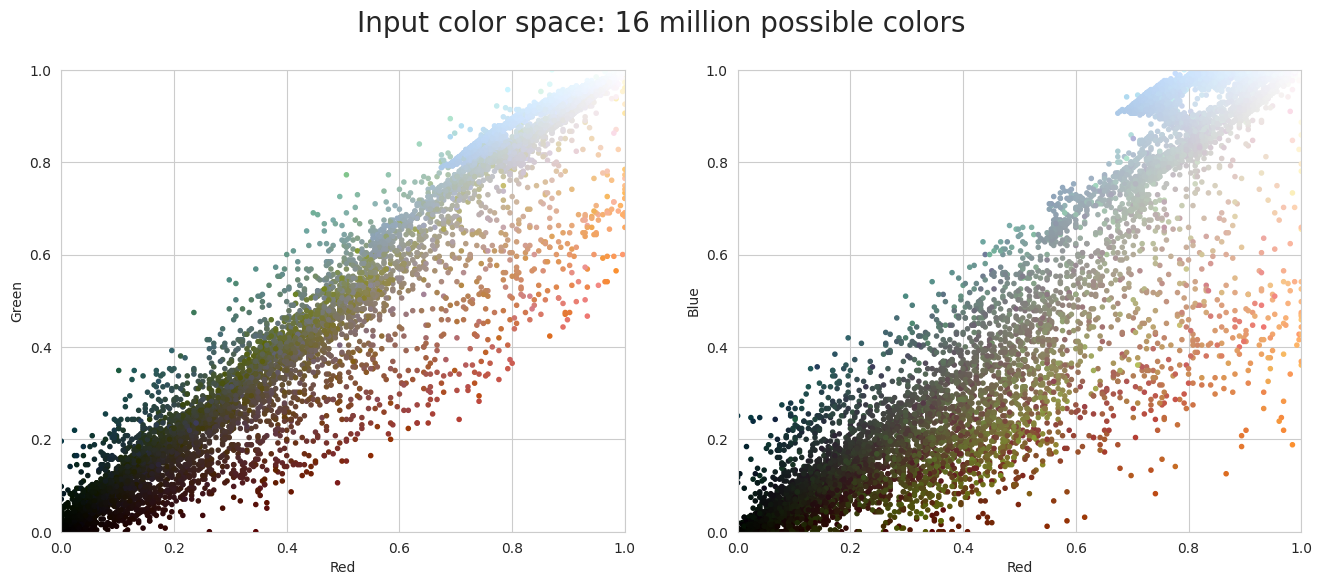

In [24]:
plot_pixels(data, title='Input color space: 16 million possible colors')

Agora, vamos reduzir essas 16 milhões de cores para apenas 16 cores, usando um algoritmo de agrupamento k-means no espaço de pixels. Como estamos lidando com um conjunto de dados muito grande, usaremos o k-means em mini-lotes, que opera em subconjuntos dos dados para calcular o resultado (mostrado na figura a seguir) muito mais rapidamente do que o algoritmo k-means padrão:

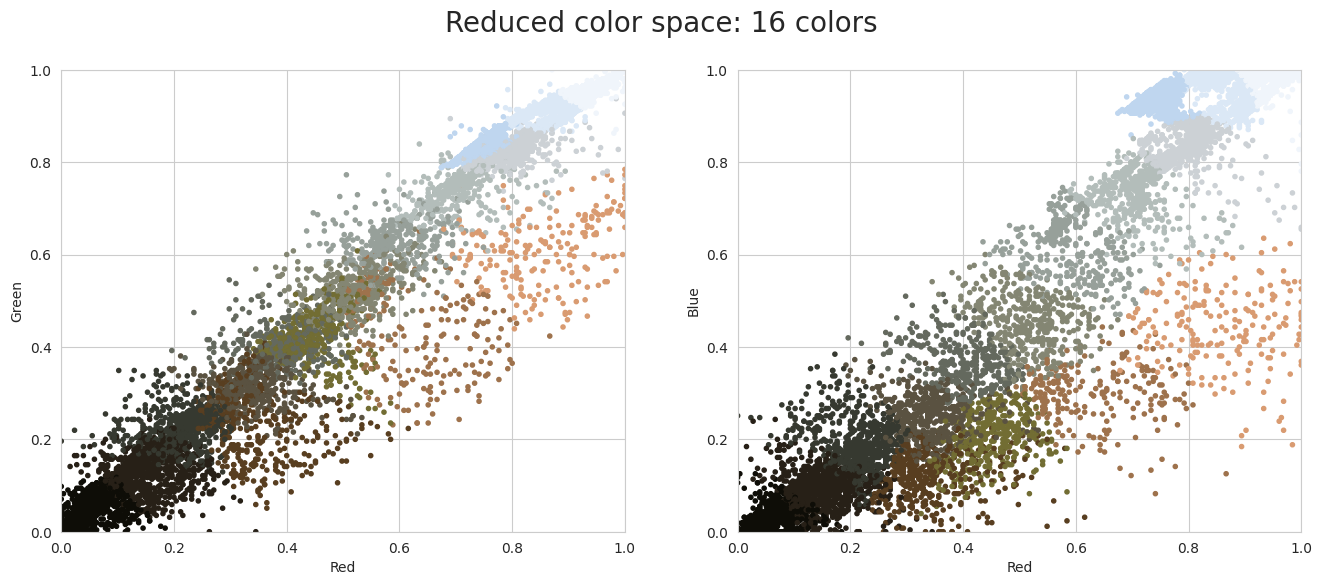

In [25]:
from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,
            title="Reduced color space: 16 colors")

O resultado é uma recoloração dos pixels originais, onde cada pixel recebe a cor do centro do cluster mais próximo. Ao plotar essas novas cores no espaço da imagem, em vez do espaço do pixel, podemos ver o efeito disso (veja a figura a seguir):

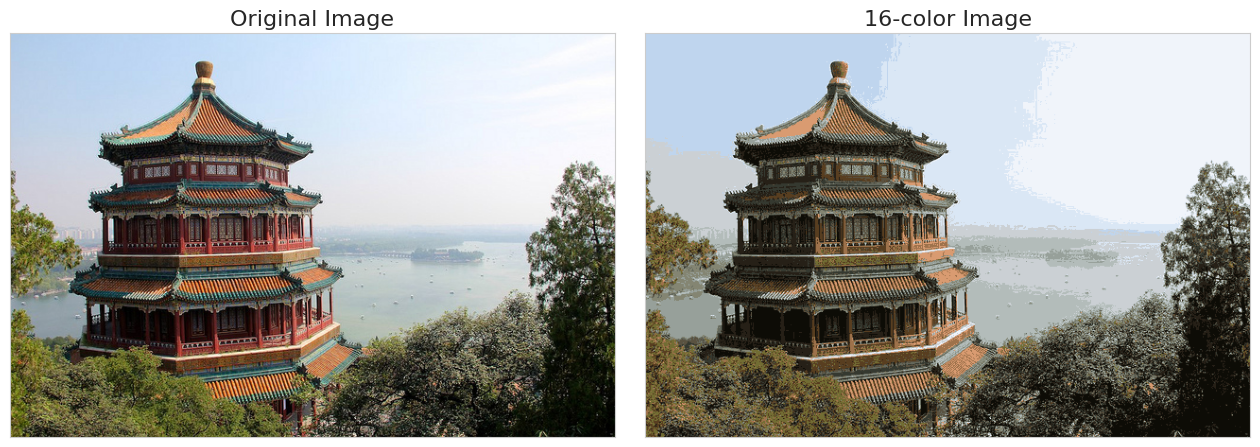

In [26]:
china_recolored = new_colors.reshape(china.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(china)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(china_recolored)
ax[1].set_title('16-color Image', size=16);

É verdade que alguns detalhes se perdem no painel mais à direita, mas a imagem como um todo ainda é facilmente reconhecível. Em termos de bytes necessários para armazenar os dados brutos, a imagem à direita atinge um fator de compressão de cerca de 1 milhão! É claro que esse tipo de abordagem não vai igualar a fidelidade de esquemas de compressão de imagem específicos, como o JPEG, mas o exemplo mostra o poder de pensar fora da caixa com métodos não supervisionados como o k-means.